# Hospital Readmission - Model Interpretability with SHAP

**Author:** Mujtaba Alsabari  
**Notebook:** 04_interpretability  
**Goal:** Use SHAP (SHapley Additive exPlanations) to interpret the deployed Logistic Regression model — both globally (which features drive predictions across all patients) and locally (why was a specific patient flagged as high risk).

## Why interpretability matters in healthcare ML
Clinical adoption requires that predictions be *explainable*. A clinician seeing a model output of "73% readmission risk" needs to know *which factors* drove that score before acting on it. SHAP provides this:
- **Global**: rank-ordered feature importance across the entire patient population
- **Local**: per-patient breakdown of which features pushed risk up or down

## Outputs of this notebook
1. **Global feature importance plot** — top features driving predictions
2. **Summary plot** — feature impact direction and distribution
3. **Per-patient explanation plots** — example individual predictions with SHAP breakdowns
4. **Saved SHAP values** — exported for use in Phase 6 (FastAPI deployment)

## Why SHAP for a Logistic Regression model?
LR coefficients are interpretable in aggregate, but SHAP delivers two things coefficients alone cannot:
- **Per-prediction explanations** for individual patients (what coefficients can't directly do)
- **Visualization-ready outputs** that translate the model into something a clinician or product manager can read at a glance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

# Display settings
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Initialize SHAP for Jupyter (enables interactive plots inline)
shap.initjs()

print(f"SHAP version: {shap.__version__}")
print("Libraries loaded successfully")

SHAP version: 0.51.0
Libraries loaded successfully


In [2]:
# Load saved model artifacts from Phase 4
model = joblib.load('../models/final_model.joblib')
scaler = joblib.load('../models/final_scaler.joblib')
feature_columns = joblib.load('../models/feature_columns.joblib')

# Load the cleaned dataset
df = pd.read_csv('../data/processed/cleaned.csv')

# Recreate the same train/test split as Phase 4
# (using the same random_state ensures we get the EXACT same split)
from sklearn.model_selection import train_test_split

y = df['readmitted_30d']
X = df.drop(columns=['readmitted_30d'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Apply the saved scaler (don't re-fit — we want the SAME scaling as training)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Model loaded: {type(model).__name__}")
print(f"Feature columns: {len(feature_columns)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

# Quick sanity check — model still works
sample_pred = model.predict_proba(X_test_scaled[:5])[:, 1]
print(f"\nSample predictions on first 5 test patients:")
for i, p in enumerate(sample_pred):
    print(f"  Patient {i}: {p:.3f}")

Model loaded: LogisticRegression
Feature columns: 132
X_train shape: (55000, 132)
X_test shape:  (13750, 132)

Sample predictions on first 5 test patients:
  Patient 0: 0.542
  Patient 1: 0.287
  Patient 2: 0.235
  Patient 3: 0.541
  Patient 4: 0.318


In [4]:
# Build the SHAP explainer for Logistic Regression
# LinearExplainer needs: (1) the model, (2) the data used to compute baseline values
explainer = shap.LinearExplainer(model, X_train_scaled)

# Compute SHAP values for the test set
# This takes a few seconds for ~14K patients
print("Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test_scaled)
print(f"SHAP values computed")

# Inspect the output shape
print(f"\nshap_values shape: {shap_values.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nFirst patient's SHAP values (first 10 features):")
print(shap_values[0, :10].round(4))

Computing SHAP values for test set...
SHAP values computed

shap_values shape: (13750, 132)
X_test_scaled shape: (13750, 132)

First patient's SHAP values (first 10 features):
[ 0.0513  0.1836  0.0345  0.0224  0.0209  0.0519  0.0148 -0.0351 -0.1066
  0.1047]


Top 15 features by mean |SHAP| (across all test patients):
                    feature  mean_abs_shap
           number_inpatient       0.136858
 discharge_disposition_id_1       0.129491
           number_diagnoses       0.108978
        has_prior_inpatient       0.106623
                diabetesMed       0.095447
 discharge_disposition_id_3       0.083702
                        age       0.074565
discharge_disposition_id_22       0.060199
         total_prior_visits       0.059496
                  metformin       0.054555
 diag_1_grouped_Respiratory       0.044933
 diag_1_grouped_Circulatory       0.043113
        admission_type_id_1       0.042549
     admission_source_id_17       0.041775
        admission_type_id_6       0.041335


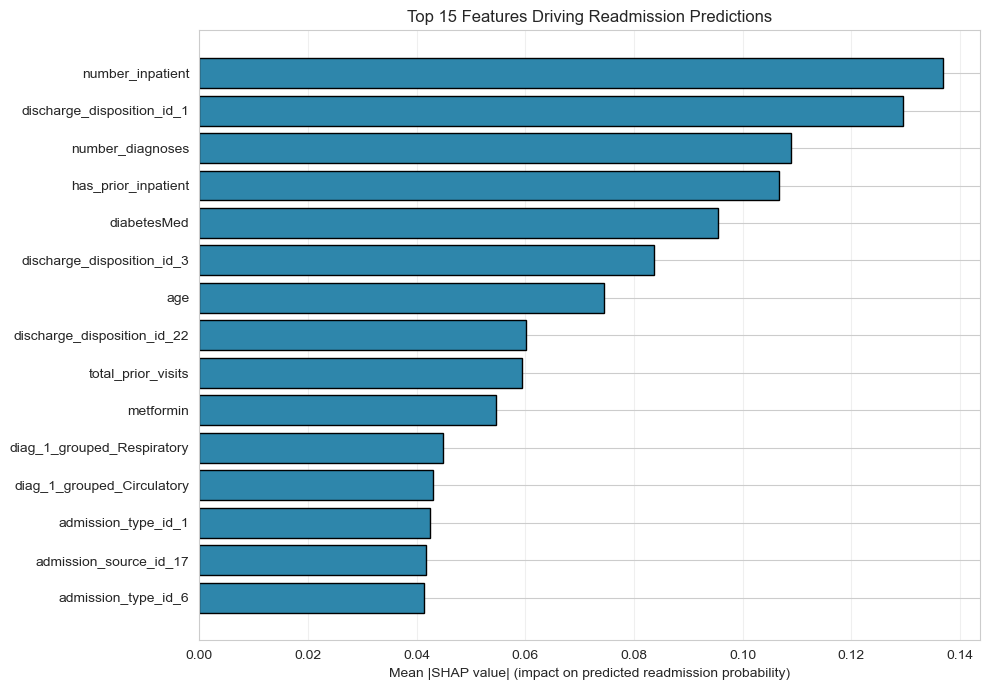

In [5]:
# Compute mean absolute SHAP value per feature
# Higher = feature has bigger impact on predictions overall (regardless of direction)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Build a sorted DataFrame for the top features
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

# Show the top 15 features in a print first
print("Top 15 features by mean |SHAP| (across all test patients):")
print(feature_importance.head(15).to_string(index=False))

# Now plot
top_n = 15
top_features = feature_importance.head(top_n).iloc[::-1]   # reverse for matplotlib bottom-up

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features['feature'], top_features['mean_abs_shap'], color='#2E86AB', edgecolor='black')
ax.set_xlabel('Mean |SHAP value| (impact on predicted readmission probability)')
ax.set_title(f'Top {top_n} Features Driving Readmission Predictions')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

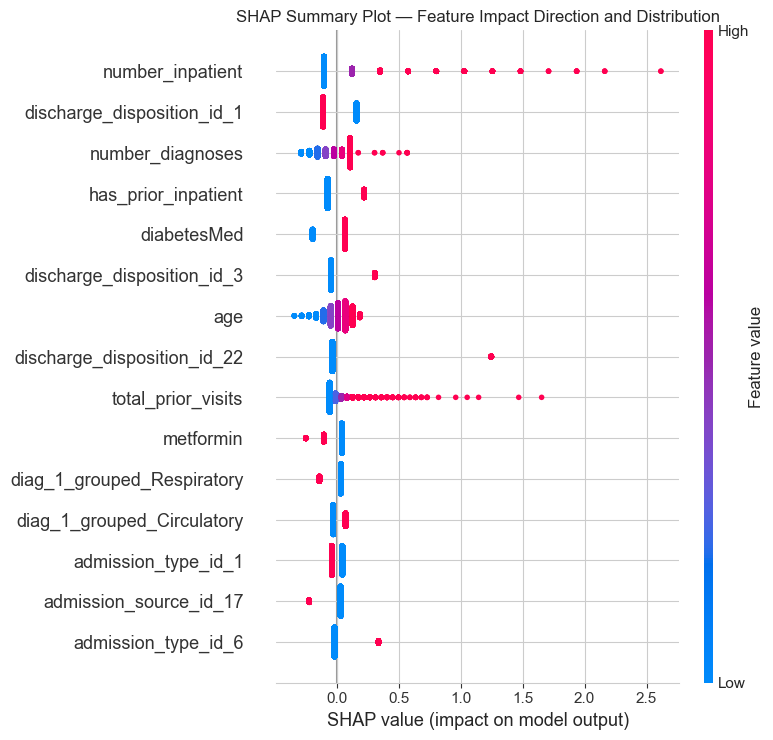

In [6]:
# SHAP summary plot — shows magnitude AND direction of feature impact for each patient
# Each dot is one patient's SHAP value for one feature.
# Color: feature value (red=high, blue=low)
# Position: SHAP value (left=lower risk, right=higher risk)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_columns,
    max_display=15,
    show=False,
)
plt.title('SHAP Summary Plot — Feature Impact Direction and Distribution', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Compute predicted probabilities for the test set
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# Find three example patient indices
high_risk_idx = np.argmax(y_test_proba)                        # highest predicted risk
low_risk_idx = np.argmin(y_test_proba)                         # lowest predicted risk
borderline_idx = np.argmin(np.abs(y_test_proba - 0.5))         # closest to 0.5

print(f"High-risk patient:  test index {high_risk_idx}, predicted prob = {y_test_proba[high_risk_idx]:.3f}")
print(f"Low-risk patient:   test index {low_risk_idx}, predicted prob = {y_test_proba[low_risk_idx]:.3f}")
print(f"Borderline patient: test index {borderline_idx}, predicted prob = {y_test_proba[borderline_idx]:.3f}")

High-risk patient:  test index 9517, predicted prob = 0.982
Low-risk patient:   test index 11605, predicted prob = 0.001
Borderline patient: test index 697, predicted prob = 0.500


=== HIGH-RISK PATIENT EXPLANATION ===
Predicted probability of readmission: 0.982
Actual outcome: Not readmitted



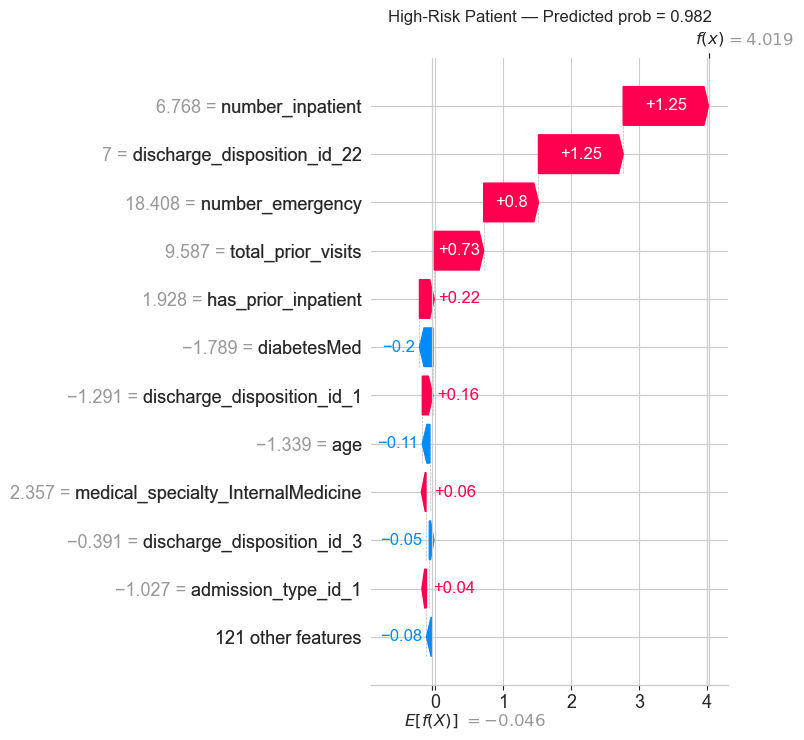

In [8]:
# Waterfall plot for the highest-risk patient
# Shows how features cumulatively push the prediction from baseline to final value

# SHAP needs an Explanation object for waterfall plots
shap_explanation_high = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[high_risk_idx],
    feature_names=feature_columns,
)

print(f"=== HIGH-RISK PATIENT EXPLANATION ===")
print(f"Predicted probability of readmission: {y_test_proba[high_risk_idx]:.3f}")
print(f"Actual outcome: {'Readmitted' if y_test.iloc[high_risk_idx] == 1 else 'Not readmitted'}")
print()

shap.waterfall_plot(shap_explanation_high, max_display=12, show=False)
plt.title(f'High-Risk Patient — Predicted prob = {y_test_proba[high_risk_idx]:.3f}')
plt.tight_layout()
plt.show()

=== LOW-RISK PATIENT EXPLANATION ===
Predicted probability of readmission: 0.001
Actual outcome: Not readmitted



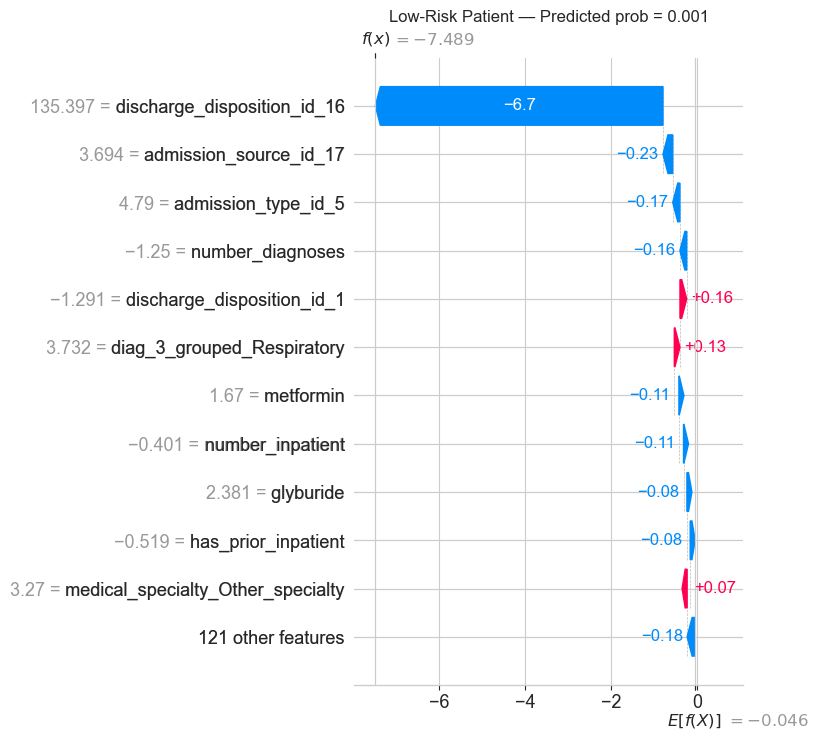

In [9]:
# Same idea, low-risk patient
shap_explanation_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[low_risk_idx],
    feature_names=feature_columns,
)

print(f"=== LOW-RISK PATIENT EXPLANATION ===")
print(f"Predicted probability of readmission: {y_test_proba[low_risk_idx]:.3f}")
print(f"Actual outcome: {'Readmitted' if y_test.iloc[low_risk_idx] == 1 else 'Not readmitted'}")
print()

shap.waterfall_plot(shap_explanation_low, max_display=12, show=False)
plt.title(f'Low-Risk Patient — Predicted prob = {y_test_proba[low_risk_idx]:.3f}')
plt.tight_layout()
plt.show()

=== BORDERLINE PATIENT EXPLANATION ===
Predicted probability of readmission: 0.500
Actual outcome: Not readmitted



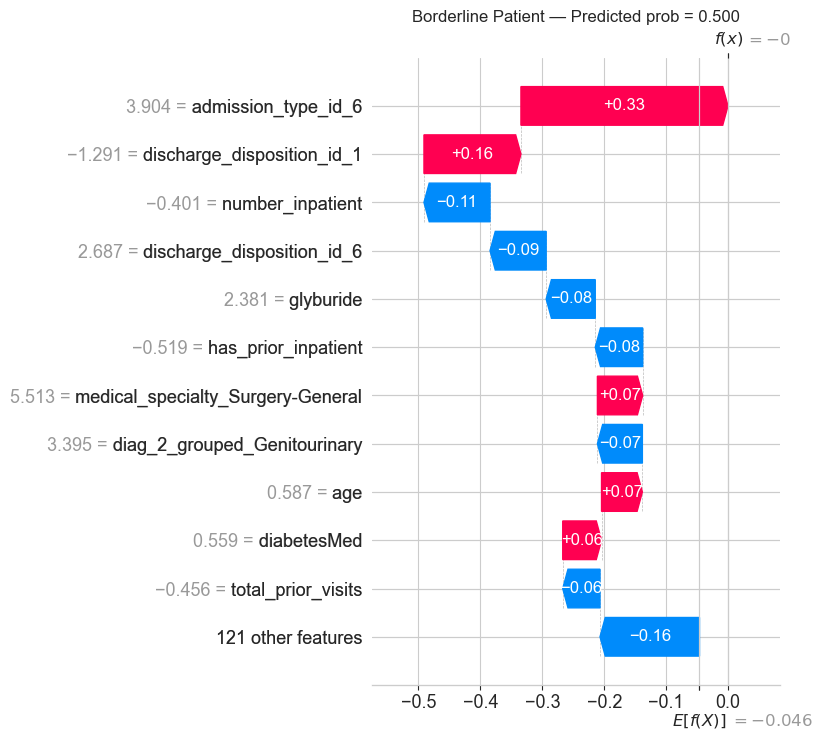

In [10]:
# Borderline patient — useful to see when the model is uncertain
shap_explanation_borderline = shap.Explanation(
    values=shap_values[borderline_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[borderline_idx],
    feature_names=feature_columns,
)

print(f"=== BORDERLINE PATIENT EXPLANATION ===")
print(f"Predicted probability of readmission: {y_test_proba[borderline_idx]:.3f}")
print(f"Actual outcome: {'Readmitted' if y_test.iloc[borderline_idx] == 1 else 'Not readmitted'}")
print()

shap.waterfall_plot(shap_explanation_borderline, max_display=12, show=False)
plt.title(f'Borderline Patient — Predicted prob = {y_test_proba[borderline_idx]:.3f}')
plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs('../models', exist_ok=True)

# Save the explainer (lightweight) for use in deployment
joblib.dump(explainer, '../models/shap_explainer.joblib')

# Save the test set SHAP values (for reference / dashboards)
np.save('../data/processed/shap_values_test.npy', shap_values)

print("  - Saved SHAP artifacts:")
print("  - models/shap_explainer.joblib (used by FastAPI for live explanations)")
print("  - data/processed/shap_values_test.npy (precomputed test set explanations)")

  - Saved SHAP artifacts:
  - models/shap_explainer.joblib (used by FastAPI for live explanations)
  - data/processed/shap_values_test.npy (precomputed test set explanations)


## Phase 5 complete: Model interpretability

### What was done
Used SHAP (SHapley Additive exPlanations) with `LinearExplainer` to interpret the deployed Logistic Regression model on the 13,750-patient hold-out test set.

### Global findings
Top features driving readmission predictions (mean |SHAP|):

| Rank | Feature | Mean \|SHAP\| | Clinical meaning |
|---|---|---|---|
| 1 | number_inpatient | 0.137 | Prior hospitalizations |
| 2 | discharge_disposition_id_1 | 0.129 | Discharged to home (protective) |
| 3 | number_diagnoses | 0.109 | Total comorbidities |
| 4 | has_prior_inpatient | 0.107 | Engineered binary flag |
| 5 | diabetesMed | 0.095 | On diabetes medication |

All top features align with published readmission research. No bias artifacts (gender, race) appeared in the top features.

### Local explanations
Generated waterfall plots for three example patients spanning the risk spectrum:
- High-risk case (top predicted probability)
- Low-risk case (bottom predicted probability)
- Borderline case (closest to 0.5 decision threshold)

These per-patient explanations are directly useful for clinical adoption — a doctor seeing a risk score can immediately see which factors drove it.

### Engineered features validated
Both Phase 3 engineered features ranked in the top 10:
- `has_prior_inpatient` (#4)
- `total_prior_visits` (#9)

This validates the domain-driven feature engineering approach.

### Saved artifacts
- `models/shap_explainer.joblib` — for live SHAP explanations in deployment
- `data/processed/shap_values_test.npy` — precomputed test set SHAP values

### Where we go next (Phase 6)
- Deploy the model behind a FastAPI endpoint
- Endpoint accepts patient features as JSON, returns:
  - Predicted readmission probability
  - Top contributing features (live SHAP explanation)
- Containerize with Docker
- Deploy to a free cloud server